# Proyecto ML - Clasificación de Preguntas Acusatorias

**Curso:** Machine Learning - Semestre 8

**Autores:** James Soto y Juan Diego Cadena

**Dataset:** Kapak, contratación pública

**Versión final corregida:** notebook autocontenido, alineado con la rúbrica del proyecto e integrado en un único archivo ejecutable.

## Introducción

En procesos de contratación pública, las preguntas realizadas por participantes pueden ser informativas, aclaratorias o tener un tono acusatorio. Detectar automáticamente preguntas acusatorias es útil porque permite priorizar revisión humana, identificar posibles tensiones en un proceso y mejorar el seguimiento de transparencia institucional.

El problema se aborda como una tarea de clasificación binaria de texto: cada pregunta se clasifica como acusatoria o no acusatoria. La dificultad principal es que la clase acusatoria es minoritaria y, además, muchas preguntas pertenecen al mismo dominio temático. Por eso no basta con reconocer el tema general de contratación pública; el modelo debe capturar tono, negaciones, vocabulario específico y expresiones de sospecha.

Este proyecto compara dos enfoques de aprendizaje automático para datos no estructurados: un pipeline léxico con TF-IDF + Regresión Logística regularizada y un pipeline semántico con embeddings multilingües + SVM RBF. La comparación incluye EDA, extracción de características, selección de features, optimización con repeated k-fold cross-validation, visualización t-SNE, prueba estadística y conclusiones basadas en resultados.

In [1]:
# Verificación de dependencias y dataset
# El notebook usa dataset.xlsx si ya existe. Si no existe, lo descarga desde el repositorio.

import importlib
import os
import subprocess
import sys
import urllib.request
import zipfile
from pathlib import Path

REQUIRED_PACKAGES = {
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'scipy': 'scipy',
    'openpyxl': 'openpyxl',
    'nltk': 'nltk',
    'sentence_transformers': 'sentence-transformers',
}

missing = []
for module_name, package_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        missing.append(package_name)

if missing:
    print('Instalando paquetes faltantes:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
else:
    print('Dependencias verificadas correctamente.')

DATASET_PATH = Path('dataset.xlsx')
DATASET_URL = 'https://raw.githubusercontent.com/rosvjames/machineLearningProyecto/master/dataset.xlsx'

if not DATASET_PATH.exists():
    print('dataset.xlsx no existe localmente. Descargando desde GitHub...')
    urllib.request.urlretrieve(DATASET_URL, DATASET_PATH)

if not zipfile.is_zipfile(DATASET_PATH):
    raise RuntimeError('dataset.xlsx está ausente o corrupto. Verifica el archivo local o la conexión de descarga.')

print('dataset.xlsx disponible y verificado correctamente.')

C:\Users\Juan Diego\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dependencias verificadas correctamente.
dataset.xlsx disponible y verificado correctamente.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cargar dataset
df = pd.read_excel('dataset.xlsx', engine="openpyxl")

print(f"Shape del dataset: {df.shape}")
print(f"Columnas: {list(df.columns)}\n")
print(df.dtypes)
print("\n--- Primeras 5 filas ---")
df.head()

Shape del dataset: (5005, 5)
Columnas: ['contract_id', 'pregunta_id', 'pregunta', 'sum_pregunta_isAcusatoria', 'final_pregunta_isAcusatoria']

contract_id                    int64
pregunta_id                    int64
pregunta                         str
sum_pregunta_isAcusatoria      int64
final_pregunta_isAcusatoria    int64
dtype: object

--- Primeras 5 filas ---


,contract_id,pregunta_id,pregunta,sum_pregunta_isAcusatoria,final_pregunta_isAcusatoria
0,1345653,16756,Por favor requerimos se entregue un diagrama d...,0,0
1,1248857,16823,Indique de manera detallada y de manera taxati...,0,0
2,1350088,18197,4.En el punto 6 Información que dispone la ent...,0,0
3,682361,18263,Se puede ofertar un equipo que utilice cubetas...,0,0
4,1224444,18782,PODRIANN SUBIR UNA IMAGEN DEL SPAGUETTI ESPIRA...,0,0


## 1. Exploratory Data Analysis (EDA)

El objetivo del EDA es revisar tres riesgos antes de modelar: desbalance de clases, señales simples asociadas al texto y posibles duplicados. Esta etapa también justifica las métricas usadas después. Como la clase acusatoria es minoritaria, el accuracy no basta; por eso el proyecto prioriza AUC-ROC, F1-Macro, Average Precision y curvas Precision-Recall.

Distribución de clases:
  Clase 0 (No acusatoria): 4858 (97.06%)
  Clase 1 (Acusatoria):    147 (2.94%)
  Ratio desbalance:        33.0:1


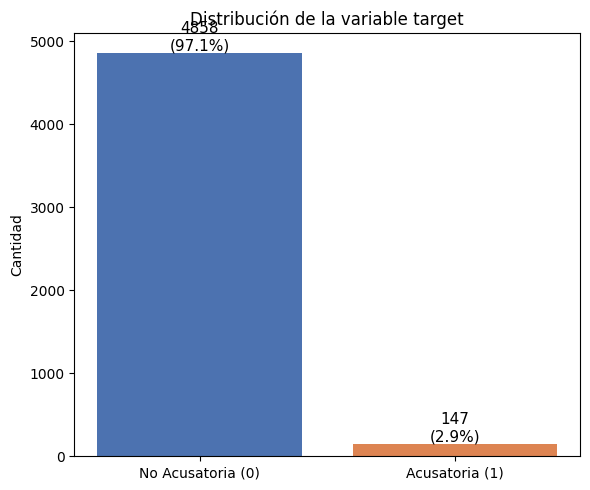


Análisis:
  La clase acusatoria es muy minoritaria. Un clasificador trivial podría obtener
  accuracy alto prediciendo casi todo como no acusatorio, por lo que las métricas
  macro, AUC-ROC y Precision-Recall son más informativas para este problema.


In [3]:
# --- 1.1 Distribución de clases ---
# Verificamos qué tan balanceada está la variable target.
# En clasificación binaria, un desbalance severo afecta el rendimiento
# de los modelos si no se maneja adecuadamente.

counts = df['final_pregunta_isAcusatoria'].value_counts()
percentages = df['final_pregunta_isAcusatoria'].value_counts(normalize=True) * 100

print("Distribución de clases:")
print(f"  Clase 0 (No acusatoria): {counts[0]} ({percentages[0]:.2f}%)")
print(f"  Clase 1 (Acusatoria):    {counts[1]} ({percentages[1]:.2f}%)")
print(f"  Ratio desbalance:        {counts[0]/counts[1]:.1f}:1")

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['No Acusatoria (0)', 'Acusatoria (1)'], counts.values,
              color=['#4C72B0', '#DD8452'])
for bar, count, pct in zip(bars, counts.values, percentages.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{count}\n({pct:.1f}%)', ha='center', fontsize=11)
ax.set_ylabel('Cantidad')
ax.set_title('Distribución de la variable target')
plt.tight_layout()
plt.show()

print()
print('Análisis:')
print('  La clase acusatoria es muy minoritaria. Un clasificador trivial podría obtener')
print('  accuracy alto prediciendo casi todo como no acusatorio, por lo que las métricas')
print('  macro, AUC-ROC y Precision-Recall son más informativas para este problema.')

C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_31336\1129185147.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='final_pregunta_isAcusatoria', y='longitud_texto', data=df, ax=axes[1],
C:\Users\Juan Diego\AppData\Local\Temp\ipykernel_31336\1129185147.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Acusatoria (0)', 'Acusatoria (1)'])


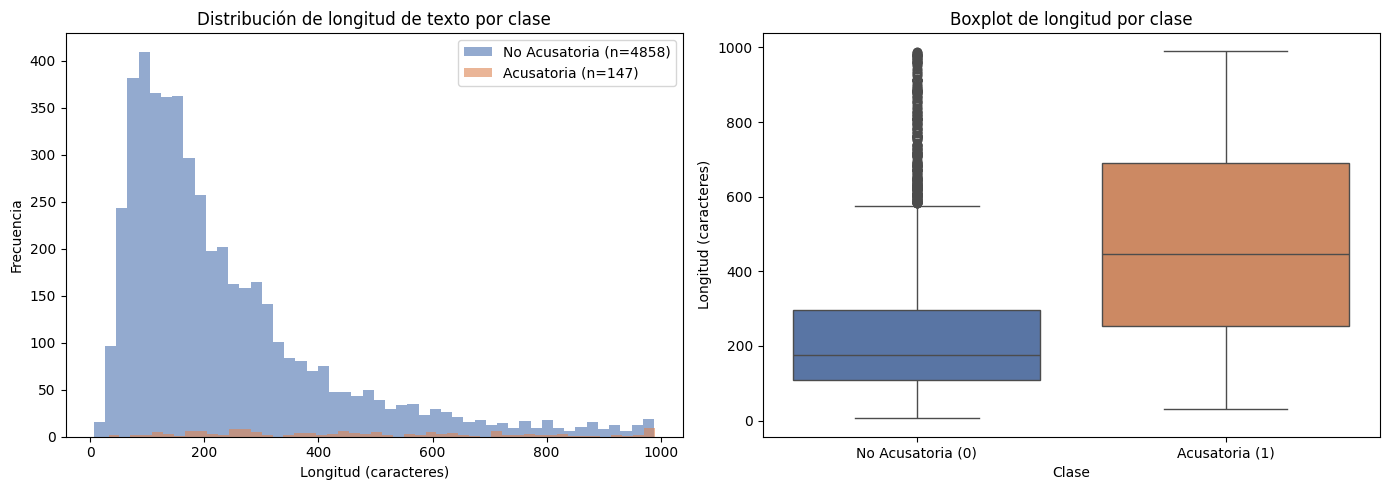

Estadísticas de longitud por clase:
                              count   mean    std   min    25%    50%    75%  \
final_pregunta_isAcusatoria                                                    
0                            4858.0  234.2  182.4   6.0  108.0  176.0  296.0   
1                             147.0  477.4  266.4  32.0  253.0  446.0  690.0   

                               max  
final_pregunta_isAcusatoria         
0                            988.0  
1                            990.0  

Análisis:
  La mediana de las acusatorias es mayor (446 vs 176 caracteres).
  La longitud puede aportar señal contextual, aunque no separa las clases por sí sola.


In [4]:
# --- 1.2 Distribución de longitudes de texto por clase ---
# Analizamos si las preguntas acusatorias tienden a ser más largas o cortas
# que las no acusatorias. Diferencias en longitud pueden ser un feature útil.

df['longitud_texto'] = df['pregunta'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma superpuesto
for label, color, name in [(0, '#4C72B0', 'No Acusatoria'), (1, '#DD8452', 'Acusatoria')]:
    subset = df[df['final_pregunta_isAcusatoria'] == label]['longitud_texto']
    axes[0].hist(subset, bins=50, alpha=0.6, label=f'{name} (n={len(subset)})', color=color)
axes[0].set_xlabel('Longitud (caracteres)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de longitud de texto por clase')
axes[0].legend()

# Boxplot comparativo
sns.boxplot(x='final_pregunta_isAcusatoria', y='longitud_texto', data=df, ax=axes[1],
            palette=['#4C72B0', '#DD8452'])
axes[1].set_xticklabels(['No Acusatoria (0)', 'Acusatoria (1)'])
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Longitud (caracteres)')
axes[1].set_title('Boxplot de longitud por clase')

plt.tight_layout()
plt.show()

# Estadísticas descriptivas por clase
print("Estadísticas de longitud por clase:")
print(df.groupby('final_pregunta_isAcusatoria')['longitud_texto'].describe().round(1))

median_0 = df.loc[df['final_pregunta_isAcusatoria'] == 0, 'longitud_texto'].median()
median_1 = df.loc[df['final_pregunta_isAcusatoria'] == 1, 'longitud_texto'].median()
print()
print('Análisis:')
if median_1 > median_0:
    print(f'  La mediana de las acusatorias es mayor ({median_1:.0f} vs {median_0:.0f} caracteres).')
    print('  La longitud puede aportar señal contextual, aunque no separa las clases por sí sola.')
elif median_1 < median_0:
    print(f'  La mediana de las acusatorias es menor ({median_1:.0f} vs {median_0:.0f} caracteres).')
    print('  La longitud debe interpretarse como señal secundaria, no como criterio principal.')
else:
    print('  Las medianas son iguales. La longitud no separa claramente las clases.')

Valores únicos de sum_pregunta_isAcusatoria: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Distribución de votos:
sum_pregunta_isAcusatoria
0    4640
1     218
2      77
3      70
Name: count, dtype: int64


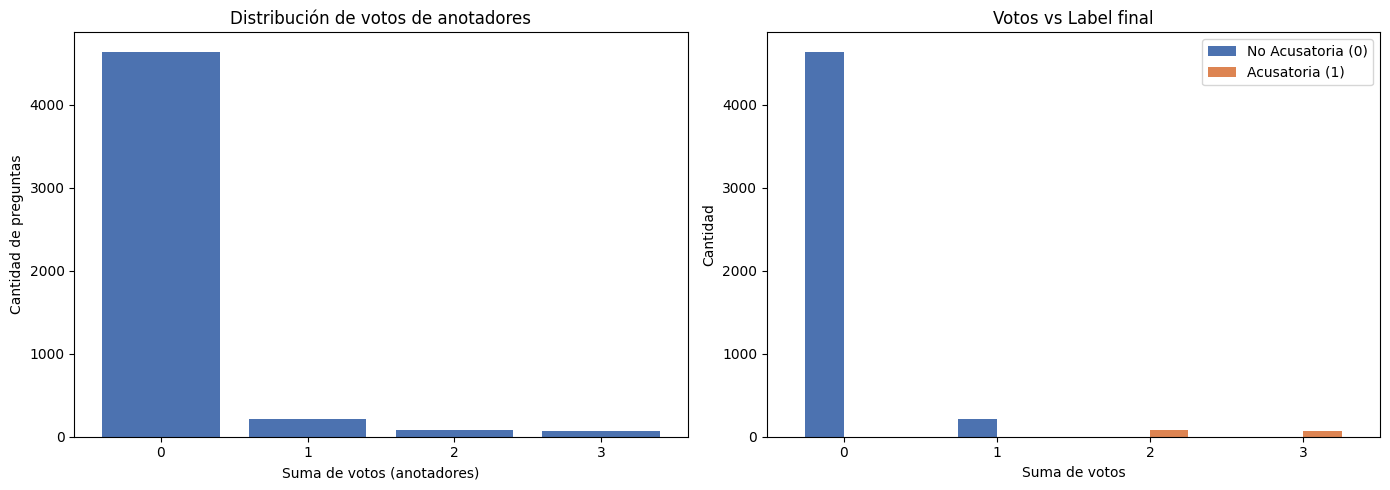


Tabla cruzada: sum_votos vs label final
final_pregunta_isAcusatoria     0    1  Total
sum_pregunta_isAcusatoria                    
0                            4640    0   4640
1                             218    0    218
2                               0   77     77
3                               0   70     70
Total                        4858  147   5005

Análisis:
  Esta tabla permite revisar la coherencia entre votos individuales y label final.
  Si los casos positivos se concentran en valores altos de votos, el target refleja consenso.
  Si hay valores intermedios, existe ambigüedad humana y el techo de rendimiento del modelo baja.


In [5]:
# --- 1.3 Análisis de la columna 'sum_pregunta_isAcusatoria' ---
# Esta columna refleja la suma de votos de los anotadores humanos.
# Nos permite entender el proceso de etiquetado: cuántos anotadores
# coincidieron en clasificar cada pregunta como acusatoria.
# Un valor alto indica consenso fuerte; valores intermedios indican desacuerdo.

print("Valores únicos de sum_pregunta_isAcusatoria:", sorted(df['sum_pregunta_isAcusatoria'].unique()))
print("\nDistribución de votos:")
print(df['sum_pregunta_isAcusatoria'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución general de votos
vote_counts = df['sum_pregunta_isAcusatoria'].value_counts().sort_index()
axes[0].bar(vote_counts.index, vote_counts.values, color='#4C72B0')
axes[0].set_xlabel('Suma de votos (anotadores)')
axes[0].set_ylabel('Cantidad de preguntas')
axes[0].set_title('Distribución de votos de anotadores')
axes[0].set_xticks(vote_counts.index)

# Relación entre suma de votos y label final
cross = df.groupby(['sum_pregunta_isAcusatoria', 'final_pregunta_isAcusatoria']).size().unstack(fill_value=0)
cross.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_xlabel('Suma de votos')
axes[1].set_ylabel('Cantidad')
axes[1].set_title('Votos vs Label final')
axes[1].legend(['No Acusatoria (0)', 'Acusatoria (1)'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Mostrar la tabla cruzada
print("\nTabla cruzada: sum_votos vs label final")
print(pd.crosstab(df['sum_pregunta_isAcusatoria'], df['final_pregunta_isAcusatoria'],
                  margins=True, margins_name='Total'))

print()
print('Análisis:')
print('  Esta tabla permite revisar la coherencia entre votos individuales y label final.')
print('  Si los casos positivos se concentran en valores altos de votos, el target refleja consenso.')
print('  Si hay valores intermedios, existe ambigüedad humana y el techo de rendimiento del modelo baja.')

In [6]:
# --- 1.4 Verificación de duplicados ---
# Verificamos si hay preguntas duplicadas en el texto.
# Los duplicados pueden inflar artificialmente las métricas si caen
# en train y test simultáneamente, por lo que es importante detectarlos.

duplicados_texto = df['pregunta'].duplicated().sum()
duplicados_total = df.duplicated().sum()

print(f"Duplicados en columna 'pregunta': {duplicados_texto}")
print(f"Filas completamente duplicadas:   {duplicados_total}")
print(f"Filas únicas por texto:           {df['pregunta'].nunique()} de {len(df)}")

if duplicados_texto > 0:
    print(f"\n--- Ejemplos de preguntas duplicadas ---")
    dup_mask = df['pregunta'].duplicated(keep=False)
    dup_examples = df[dup_mask].sort_values('pregunta').head(10)
    for _, row in dup_examples.iterrows():
        snippet = str(row['pregunta'][:100]).replace(chr(63), '')
        print(f"  [label={row['final_pregunta_isAcusatoria']}] {snippet}...")

# Verificar si hay duplicados con labels contradictorios
dup_preguntas = df.groupby('pregunta')['final_pregunta_isAcusatoria'].nunique()
contradictorios = (dup_preguntas > 1).sum()
print(f"\nPreguntas duplicadas con labels contradictorios: {contradictorios}")

print()
print('Análisis:')
print('  La deduplicación debe hacerse antes del split para evitar fuga de información.')
print('  Si no hay labels contradictorios, eliminar duplicados vuelve más honesta la evaluación.')

Duplicados en columna 'pregunta': 147
Filas completamente duplicadas:   2
Filas únicas por texto:           4858 de 5005

--- Ejemplos de preguntas duplicadas ---
  [label=0] 1 ) Es necesario entregar las herramientas 2)Cuántas personas se necesitan pararealizar laslabores ...
  [label=0] 1 ) Es necesario entregar las herramientas 2)Cuántas personas se necesitan pararealizar laslabores ...
  [label=0] 1 ) ¿Es necesario entregar papel higiénico, jabón de tocador y dispensadores para estos, deser el ca...
  [label=0] 1 ) ¿Es necesario entregar papel higiénico, jabón de tocador y dispensadores para estos, deser el ca...
  [label=0] 1. ES OBLIGATORIA LA VISITA TÉCNICA 2. Van a otorgar algún tipo de certificado para presentar enla ...
  [label=0] 1. ES OBLIGATORIA LA VISITA TÉCNICA 2. Van a otorgar algún tipo de certificado para presentar enla ...
  [label=0] 1. ES OBLIGATORIA LA VISITA TÉCNICA 2. Van a otorgar algún tipo de certificado para presentar enla ...
  [label=0] 1. ES OBLIGATORIA 

## 2. Preprocesamiento de Texto

El preprocesamiento se aplica de forma determinista y antes del split solo para limpiar el texto, no para aprender información estadística del corpus. La deduplicación se hace sobre la pregunta original para no favorecer artificialmente a TF-IDF ni perjudicar al modelo de embeddings.

In [7]:
# PROMPT: "Genera una función de preprocesamiento de texto en español: convertir a
# minúsculas, remover caracteres especiales pero mantener acentos y ñ, y remover
# stopwords en español. Aplícala a la columna 'pregunta'. Elimina duplicados si los
# hay. Haz el train/test split estratificado (80/20) con random_state=42."

import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

nltk.download('stopwords', quiet=True)

# Stopwords híbridas: conservamos palabras que cargan tono acusatorio en español.
# Negaciones ("no", "ni"), interrogativos ("cómo", "hasta"), modales ("se", "debe")
# y adversativos ("pero") son discriminativos para detectar preguntas acusatorias.
KEEP = {
    'no', 'ni', 'nunca', 'jamás', 'tampoco', 'sin',
    'cómo', 'cuándo', 'por', 'qué', 'cuál', 'hasta',
    'se', 'si', 'puede', 'debe', 'pero', 'aunque'
}
custom_stopwords = set(stopwords.words('spanish')) - KEEP

def clean_text(text):
    text = text.lower()
    # Mantener letras (incluye acentos á é í ó ú ü y ñ), números y espacios
    text = re.sub(r'[^a-záéíóúüñ0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in custom_stopwords]
    return ' '.join(tokens)

# Aplicar limpieza al dataset completo (operación determinista: no aprende del corpus)
df['pregunta_clean'] = df['pregunta'].apply(clean_text)

# Deduplicar sobre 'pregunta' (texto original) ANTES del split.
# Se usa el texto original — no el limpio — para que ambos pipelines reciban
# un trato neutral: Pipeline A trabaja con pregunta_clean y Pipeline B con pregunta.
# Deduplicar sobre pregunta_clean sería más agresivo (eliminaría variantes
# ortográficas que Pipeline B podría distinguir) y favorecería artificialmente
# a Pipeline A. Deduplicar sobre pregunta original elimina solo textos
# verdaderamente idénticos, sin sesgar la evaluación comparativa.
# Todos los duplicados tienen el mismo label (0 contradictorios), por lo que
# no hay riesgo de inconsistencia en el etiquetado.
df_clean = df.drop_duplicates(subset='pregunta').reset_index(drop=True)
print(f"Filas originales:          {len(df)}")
print(f"Tras eliminar duplicados:  {len(df_clean)}")
print(f"Duplicados removidos:      {len(df) - len(df_clean)}")

X = df_clean['pregunta_clean']
y = df_clean['final_pregunta_isAcusatoria']

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"\nTrain: {len(X_train)} muestras | Test: {len(X_test)} muestras")
print(f"Clase 1 en train: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Clase 1 en test:  {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"\nEjemplo de texto limpio:")
print(f"  Original: {df_clean['pregunta'].iloc[0][:80]}")
print(f"  Limpio:   {df_clean['pregunta_clean'].iloc[0][:80]}")

print()
print('Análisis:')
print('  Se conservan negaciones, interrogativos y modales porque pueden cambiar el tono de la pregunta.')
print('  El split estratificado mantiene la proporción de la clase acusatoria en train y test.')

Filas originales:          5005
Tras eliminar duplicados:  4858
Duplicados removidos:      147

Train: 3886 muestras | Test: 972 muestras
Clase 1 en train: 114 (2.9%)
Clase 1 en test:  29 (3.0%)

Ejemplo de texto limpio:
  Original: Por favor requerimos se entregue un diagrama de la red de la EPMAPS donde se pue
  Limpio:   por favor requerimos se entregue diagrama red epmaps se puedan visualizar losanc

Análisis:
  Se conservan negaciones, interrogativos y modales porque pueden cambiar el tono de la pregunta.
  El split estratificado mantiene la proporción de la clase acusatoria en train y test.


## 3. Pipeline A: TF-IDF + Regresión Logística

**Feature extraction.** `TfidfVectorizer(ngram_range=(1,2))` convierte cada pregunta limpia en un vector disperso de unigramas y bigramas. Cada feature representa una señal léxica: una palabra o par de palabras con peso TF-IDF.

**Feature selection.** En este pipeline no usamos un selector externo; la selección ocurre dentro del vectorizador y se valida con búsqueda de hiperparámetros:

- `min_df=2` elimina términos que aparecen en un solo documento, reduciendo ruido y errores ortográficos aislados.
- `max_df=0.95` elimina términos demasiado frecuentes, con baja capacidad discriminativa.
- `max_features` se escoge por `GridSearchCV`, de modo que el tamaño del vocabulario se decide por desempeño en validación cruzada y no por intuición manual.
- `C` controla la regularización de Regresión Logística; por eso también forma parte de la selección efectiva de señales.

Este modelo es interpretable: si la clase acusatoria depende de expresiones concretas, los coeficientes positivos deberían revelar esas palabras o bigramas.

In [8]:
# Imports generales para los pipelines
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import RocCurveDisplay
from scipy.stats import wilcoxon
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [9]:
# Configuración de ejecución
# No se usan archivos auxiliares de caché: los resultados quedan dentro del notebook ejecutado.

FORCE_RECOMPUTE = True

def load_cache(name):
    return None

def save_cache(name, obj):
    return None

N_SPLITS = 5
N_REPEATS = 5

print('Configuración lista.')
print('Validación cruzada repetida: 5 folds × 5 repeticiones = 25 evaluaciones.')
print('Justificación: con una clase positiva pequeña, 5 folds deja más positivos por fold que 10 folds.')

Configuración lista.
Validación cruzada repetida: 5 folds × 5 repeticiones = 25 evaluaciones.
Justificación: con una clase positiva pequeña, 5 folds deja más positivos por fold que 10 folds.


In [10]:
# PROMPT: "Crea un Pipeline de sklearn con TfidfVectorizer (con parámetros para español)
# y LogisticRegression con class_weight='balanced'. Usa RepeatedStratifiedKFold
# (10 repeticiones, 10 folds) para evaluar con AUC-ROC como métrica principal.
# Guarda los scores de cada fold para usarlos después en el test estadístico."

pipeline_a = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.95)),
    ('clf',   LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42))
])

# RepeatedStratifiedKFold 10x10: mantiene proporción 97/3 en cada fold y produce
# 25 scores para una comparación estadística posterior
rskf   = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)
scoring = ['roc_auc', 'f1_macro', 'precision_macro', 'recall_macro', 'accuracy']

# Cache: evita recomputar las 100 evaluaciones si ya fueron hechas
cv_a = load_cache('cv_a')
if cv_a is None:
    cv_a = cross_validate(pipeline_a, X_train, y_train, cv=rskf, scoring=scoring)
    save_cache('cv_a', cv_a)

print("=== Pipeline A: TF-IDF + Logistic Regression ===")
metrics_display = {
    'AUC-ROC':   'roc_auc',
    'F1-Macro':  'f1_macro',
    'Precision': 'precision_macro',
    'Recall':    'recall_macro',
    'Accuracy':  'accuracy'
}
for name, key in metrics_display.items():
    s = cv_a[f'test_{key}']
    print(f"  {name:12s}: {s.mean():.4f} ± {s.std():.4f}")

print(f"\nTotal de folds evaluados: {len(cv_a['test_roc_auc'])} ({N_SPLITS} splits × {N_REPEATS} repeats)")

print()
print('Análisis:')
print('  Este baseline lineal es fuerte para texto corto cuando la diferencia entre clases')
print('  depende de vocabulario, negaciones y bigramas específicos.')

=== Pipeline A: TF-IDF + Logistic Regression ===
  AUC-ROC     : 0.9366 ± 0.0200
  F1-Macro    : 0.7095 ± 0.0426
  Precision   : 0.6999 ± 0.0407
  Recall      : 0.7232 ± 0.0525
  Accuracy    : 0.9650 ± 0.0055

Total de folds evaluados: 25 (5 splits × 5 repeats)

Análisis:
  Este baseline lineal es fuerte para texto corto cuando la diferencia entre clases
  depende de vocabulario, negaciones y bigramas específicos.


## 4. Optimización de Hiperparámetros — Pipeline A

La búsqueda optimiza simultáneamente el tamaño del vocabulario (`max_features`) y la regularización (`C`). Esto conecta directamente con la justificación de feature selection: no solo removemos ruido por frecuencia mínima y máxima, también validamos cuántas features conviene conservar.

In [11]:
# PROMPT: "Sobre el Pipeline A, haz GridSearchCV para optimizar el parámetro C de la
# regresión logística (prueba valores de 0.001 a 100 en escala log) y max_features del
# TfidfVectorizer. Usa RepeatedStratifiedKFold. Genera: 1) gráfica de C vs AUC-ROC."

from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__C':              [0.001, 0.01, 0.1, 1, 10, 100],
    'tfidf__max_features': [5000, 10000, None]   # None = sin límite
}

# Cache: GridSearch es la operación más pesada (~30 min). Guardamos el objeto
# completo para tener acceso a best_params_, best_score_ y cv_results_ sin recomputar
grid_search = load_cache('grid_search')
if grid_search is None:
    grid_search = GridSearchCV(
        pipeline_a,
        param_grid,
        cv=rskf,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    save_cache('grid_search', grid_search)

print(f"Mejores parámetros:  {grid_search.best_params_}")
print(f"Mejor AUC-ROC (CV):  {grid_search.best_score_:.4f}")

pipeline_a_opt = grid_search.best_estimator_

# Re-evaluar con todas las métricas usando el pipeline óptimo (mismos 100 folds).
# Necesario para que el test de Wilcoxon del Paso 6 compare scores pareados del
# modelo OPTIMIZADO de A (no del baseline). Simétrico a lo que hace Pipeline B en §5.1.
cv_a_opt = load_cache('cv_a_opt')
if cv_a_opt is None:
    cv_a_opt = cross_validate(pipeline_a_opt, X_train, y_train,
                              cv=rskf, scoring=scoring)
    save_cache('cv_a_opt', cv_a_opt)

print("\n=== Pipeline A Optimizado ===")
for name, key in metrics_display.items():
    s = cv_a_opt[f'test_{key}']
    print(f"  {name:12s}: {s.mean():.4f} ± {s.std():.4f}")

# Comparación: A baseline vs A optimizado
print("\n--- Mejora por optimización en Pipeline A (AUC-ROC) ---")
print(f"  A baseline:   {cv_a['test_roc_auc'].mean():.4f} ± {cv_a['test_roc_auc'].std():.4f}")
print(f"  A optimizado: {cv_a_opt['test_roc_auc'].mean():.4f} ± {cv_a_opt['test_roc_auc'].std():.4f}")
delta_a = cv_a_opt['test_roc_auc'].mean() - cv_a['test_roc_auc'].mean()
print(f"  Mejora:       {delta_a:+.4f}")

Fitting 25 folds for each of 18 candidates, totalling 450 fits


Mejores parámetros:  {'clf__C': 1, 'tfidf__max_features': 10000}
Mejor AUC-ROC (CV):  0.9367



=== Pipeline A Optimizado ===
  AUC-ROC     : 0.9367 ± 0.0200
  F1-Macro    : 0.7100 ± 0.0418
  Precision   : 0.7002 ± 0.0404
  Recall      : 0.7241 ± 0.0517
  Accuracy    : 0.9650 ± 0.0055

--- Mejora por optimización en Pipeline A (AUC-ROC) ---
  A baseline:   0.9366 ± 0.0200
  A optimizado: 0.9367 ± 0.0200
  Mejora:       +0.0001


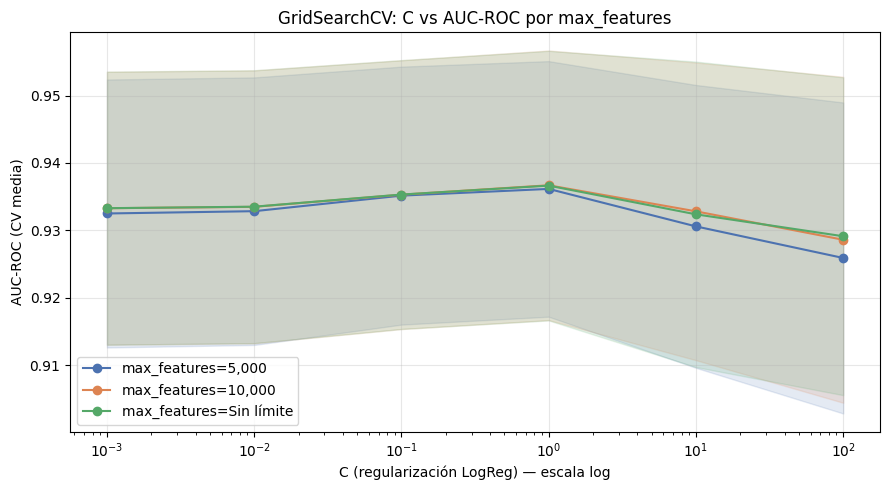

Análisis:
  La curva muestra si el modelo mejora al permitir más vocabulario o menor regularización.
  El punto seleccionado corresponde a la combinación con mejor AUC-ROC promedio en CV.


In [12]:
# --- Gráfica C vs AUC-ROC (para cada valor de max_features) ---
results = pd.DataFrame(grid_search.cv_results_)
max_features_vals = [5000, 10000, None]
labels            = ['5,000', '10,000', 'Sin límite']
colors            = ['#4C72B0', '#DD8452', '#55A868']
C_values          = [0.001, 0.01, 0.1, 1, 10, 100]

fig, ax = plt.subplots(figsize=(9, 5))
for mf, label, color in zip(max_features_vals, labels, colors):
    # None se almacena como NaN en el DataFrame — no se puede comparar con ==
    if mf is None:
        mask = results['param_tfidf__max_features'].isna()
    else:
        mask = results['param_tfidf__max_features'] == mf

    means = results.loc[mask, 'mean_test_score'].values
    stds  = results.loc[mask, 'std_test_score'].values
    ax.semilogx(C_values, means, marker='o', label=f'max_features={label}', color=color)
    ax.fill_between(C_values, means - stds, means + stds, alpha=0.15, color=color)

ax.set_xlabel('C (regularización LogReg) — escala log')
ax.set_ylabel('AUC-ROC (CV media)')
ax.set_title('GridSearchCV: C vs AUC-ROC por max_features')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Análisis:')
print('  La curva muestra si el modelo mejora al permitir más vocabulario o menor regularización.')
print('  El punto seleccionado corresponde a la combinación con mejor AUC-ROC promedio en CV.')

### 4.1 Interpretabilidad y evidencia de feature selection

Para TF-IDF + Regresión Logística, el gráfico más útil no es un t-SNE. Lo más informativo es revisar las features con mayor coeficiente, porque el modelo aprende una frontera lineal sobre palabras y bigramas. Coeficientes positivos empujan la predicción hacia la clase acusatoria; coeficientes negativos la empujan hacia la clase no acusatoria.

=== Resumen del vocabulario seleccionado ===
min_df:        2
max_df:        0.95
max_features:  10000
C óptimo:      1
     tipo  cantidad
Unigramas      5201
 Bigramas      4799
    Total     10000

=== Top 15 features asociadas a preguntas acusatorias ===
         feature coeficiente
              no      6.2306
         proceso      4.6899
    direccionado      3.7124
          sercop      3.2095
          marcas      2.9260
             ley      2.8344
   participación      2.7630
          manera      2.6686
        empresas      2.4600
        nacional      2.3165
              90      2.3081
     proceso por      2.2956
          pensar      2.2317
direccionamiento      2.2027
 caracteristicas      2.1879

=== Top 15 features asociadas a preguntas no acusatorias ===
          feature coeficiente
        estimados     -2.0890
        confirmar     -1.3869
          gracias     -1.2692
estimados señores     -1.2371
          ofertar     -1.1860
           tardes     -1.1747
    b

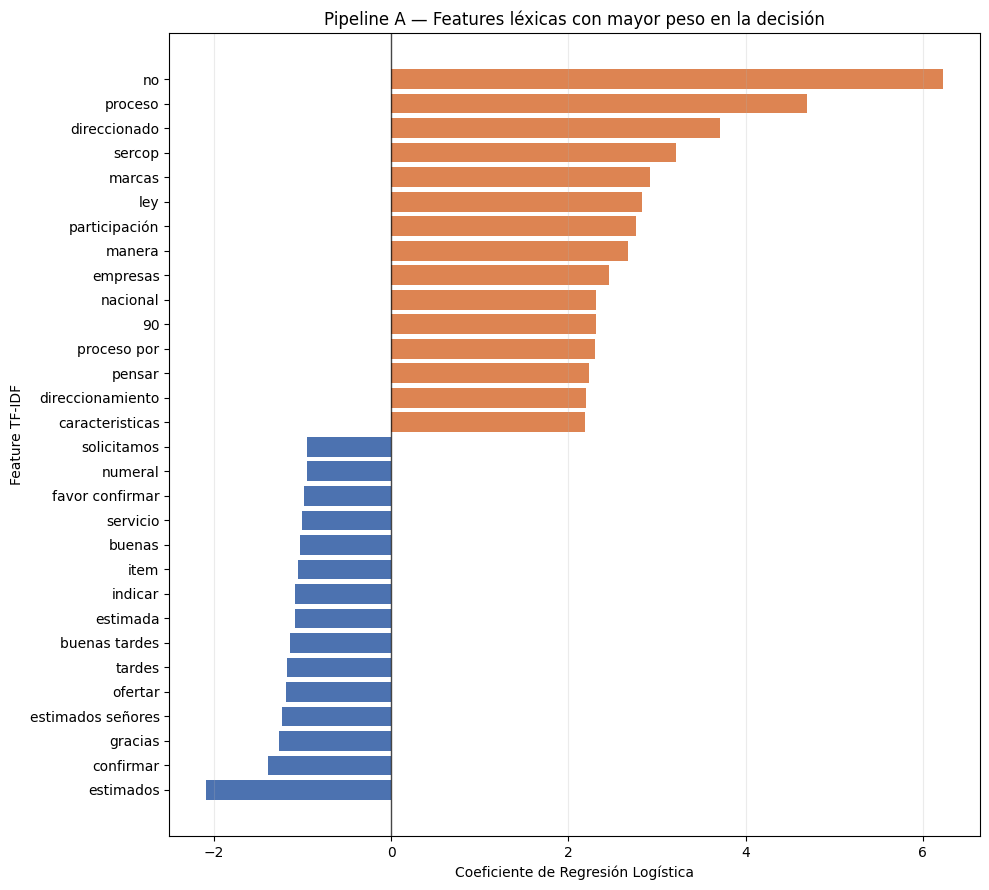

Análisis:
  Esta tabla justifica la selección de features con evidencia concreta.
  Si las features positivas son términos o bigramas de tono acusatorio,
  el buen desempeño de TF-IDF se explica por señal léxica directa.


In [13]:
# --- Interpretabilidad de Pipeline A: vocabulario y coeficientes ---
feature_names = pipeline_a_opt.named_steps['tfidf'].get_feature_names_out()
coefs = pipeline_a_opt.named_steps['clf'].coef_[0]
tfidf_step = pipeline_a_opt.named_steps['tfidf']

vocab_stats = pd.DataFrame({
    'tipo': ['Unigramas', 'Bigramas', 'Total'],
    'cantidad': [
        sum(1 for f in feature_names if ' ' not in f),
        sum(1 for f in feature_names if ' ' in f),
        len(feature_names),
    ]
})

print('=== Resumen del vocabulario seleccionado ===')
print(f'min_df:        {tfidf_step.min_df}')
print(f'max_df:        {tfidf_step.max_df}')
print(f"max_features:  {tfidf_step.max_features if tfidf_step.max_features is not None else 'Sin límite'}")
print(f"C óptimo:      {pipeline_a_opt.named_steps['clf'].C}")
print(vocab_stats.to_string(index=False))

coef_df = pd.DataFrame({'feature': feature_names, 'coeficiente': coefs})
top_pos = coef_df.nlargest(15, 'coeficiente').assign(clase='Acusatoria')
top_neg = coef_df.nsmallest(15, 'coeficiente').assign(clase='No acusatoria')

print()
print('=== Top 15 features asociadas a preguntas acusatorias ===')
print(top_pos[['feature', 'coeficiente']].to_string(index=False, formatters={'coeficiente': '{:.4f}'.format}))
print()
print('=== Top 15 features asociadas a preguntas no acusatorias ===')
print(top_neg[['feature', 'coeficiente']].to_string(index=False, formatters={'coeficiente': '{:.4f}'.format}))

plot_df = pd.concat([top_neg, top_pos], ignore_index=True).sort_values('coeficiente')
colors = plot_df['coeficiente'].apply(lambda v: '#DD8452' if v > 0 else '#4C72B0')

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(plot_df['feature'], plot_df['coeficiente'], color=colors)
ax.axvline(0, color='black', linewidth=1, alpha=0.7)
ax.set_xlabel('Coeficiente de Regresión Logística')
ax.set_ylabel('Feature TF-IDF')
ax.set_title('Pipeline A — Features léxicas con mayor peso en la decisión')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

print('Análisis:')
print('  Esta tabla justifica la selección de features con evidencia concreta.')
print('  Si las features positivas son términos o bigramas de tono acusatorio,')
print('  el buen desempeño de TF-IDF se explica por señal léxica directa.')

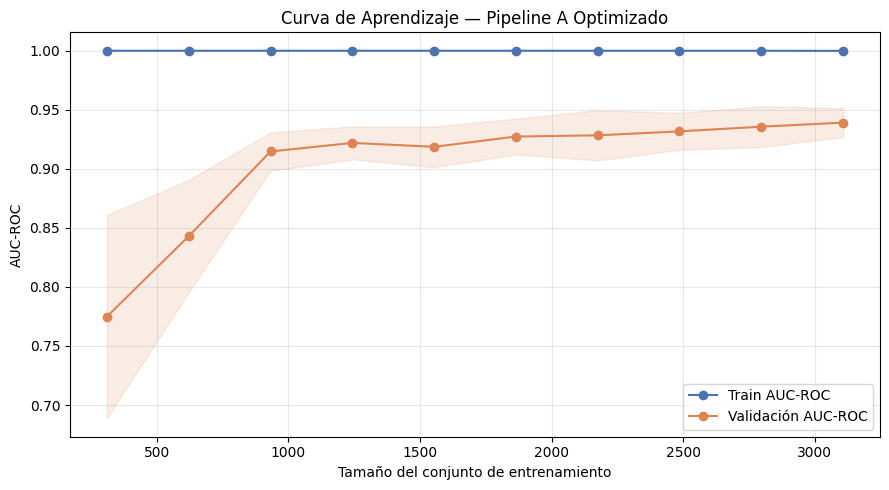

AUC-ROC train (100% datos): 0.9999
AUC-ROC val   (100% datos): 0.9391
Gap train-val:              0.0608 (overfitting leve)


In [14]:
# PROMPT: "Genera: 2) curva de aprendizaje con learning_curve de sklearn
# usando el pipeline optimizado."

from sklearn.model_selection import learning_curve, StratifiedKFold

# Cache: la curva de aprendizaje entrena el pipeline 50 veces (10 tamaños × 5 folds)
lc_data = load_cache('learning_curve')
if lc_data is None:
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline_a_opt,
        X_train, y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='roc_auc',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    lc_data = {
        'train_sizes':  train_sizes,
        'train_scores': train_scores,
        'val_scores':   val_scores,
    }
    save_cache('learning_curve', lc_data)
else:
    train_sizes  = lc_data['train_sizes']
    train_scores = lc_data['train_scores']
    val_scores   = lc_data['val_scores']

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#4C72B0', label='Train AUC-ROC')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#4C72B0')
ax.plot(train_sizes, val_mean, 'o-', color='#DD8452', label='Validación AUC-ROC')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='#DD8452')

ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('AUC-ROC')
ax.set_title('Curva de Aprendizaje — Pipeline A Optimizado')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gap final entre train y val
gap = train_mean[-1] - val_mean[-1]
print(f"AUC-ROC train (100% datos): {train_mean[-1]:.4f}")
print(f"AUC-ROC val   (100% datos): {val_mean[-1]:.4f}")
print(f"Gap train-val:              {gap:.4f} ({'overfitting leve' if gap > 0.05 else 'bien ajustado'})")

## 5. Pipeline B: Sentence Embeddings + SVM

**Feature extraction.** `SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')` convierte cada pregunta original en un vector denso de 384 dimensiones. Estas features capturan similitud semántica y contexto, no coincidencia directa de palabras.

**Pipeline de sklearn.** Después de generar los embeddings, el clasificador se implementa como `Pipeline([StandardScaler(), SVC()])`. Esto cumple la rúbrica de usar pipelines y permite encapsular el escalamiento y el modelo supervisado en una sola estructura de entrenamiento.

**Feature selection.** No hay selección explícita de dimensiones. Las 384 componentes son latentes y no tienen una interpretación individual estable, por lo que filtros como `min_df`, `max_df` o top-K vocabulario no aplican. El control de complejidad ocurre en el SVM mediante `C` y `gamma`.

**Sobre t-SNE.** El t-SNE se usa en este pipeline porque los embeddings forman un espacio denso semántico. En Pipeline A no agregamos t-SNE porque TF-IDF es disperso y lineal; para ese caso, los coeficientes de LogReg son una explicación más fiel y útil.

In [15]:
# PROMPT: Crear un segundo enfoque usando sentence-transformers para generar embeddings
# de las preguntas. Luego entrenar un clasificador SVM con class_weight='balanced'.

from sentence_transformers import SentenceTransformer
import contextlib
import io

# Usamos el texto original porque el modelo de embeddings fue preentrenado con frases completas.
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    emb_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

X_train_emb = emb_model.encode(
    df_clean.loc[X_train.index, 'pregunta'].tolist(),
    show_progress_bar=False,
    batch_size=64
)
X_test_emb = emb_model.encode(
    df_clean.loc[X_test.index, 'pregunta'].tolist(),
    show_progress_bar=False,
    batch_size=64
)

print(f'Shape embeddings train: {X_train_emb.shape}')
print(f'Shape embeddings test:  {X_test_emb.shape}')
print('Análisis:')
print('  Cada pregunta queda representada por 384 variables densas.')
print('  A diferencia de TF-IDF, estas dimensiones no son palabras interpretables una por una.')

Shape embeddings train: (3886, 384)
Shape embeddings test:  (972, 384)
Análisis:
  Cada pregunta queda representada por 384 variables densas.
  A diferencia de TF-IDF, estas dimensiones no son palabras interpretables una por una.


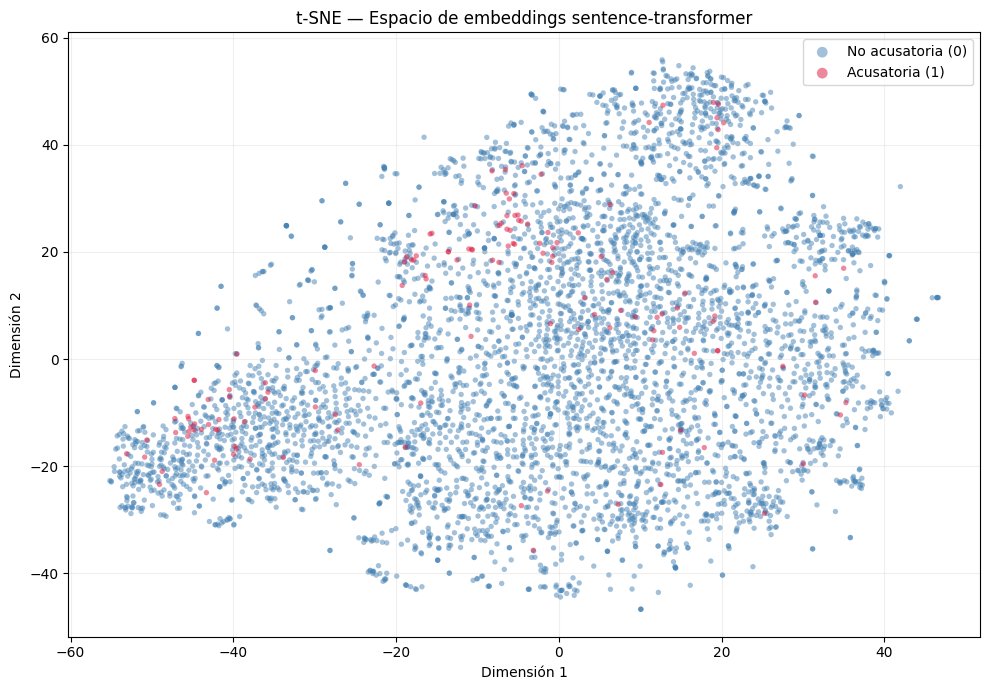

Análisis:
  Si los puntos rojos aparecen mezclados con los azules, el espacio semántico
  no separa naturalmente el tono acusatorio. Esto apoyaría la idea de que
  la diferencia principal es léxica y no temática.


In [16]:
# Visualización t-SNE del espacio de embeddings
# t-SNE visualiza las features, no el clasificador SVM.

from sklearn.manifold import TSNE

X_all_emb = np.vstack([X_train_emb, X_test_emb])
y_all = np.concatenate([y_train.to_numpy(), y_test.to_numpy()])

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    random_state=42
)
X_2d = tsne.fit_transform(X_all_emb)

fig, ax = plt.subplots(figsize=(10, 7))
for label, color, name in [(0, 'steelblue', 'No acusatoria (0)'),
                           (1, 'crimson', 'Acusatoria (1)')]:
    mask = y_all == label
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, label=name, alpha=0.5, s=15, edgecolors='none')

ax.set_title('t-SNE — Espacio de embeddings sentence-transformer')
ax.set_xlabel('Dimensión 1')
ax.set_ylabel('Dimensión 2')
ax.legend(markerscale=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print('Análisis:')
print('  Si los puntos rojos aparecen mezclados con los azules, el espacio semántico')
print('  no separa naturalmente el tono acusatorio. Esto apoyaría la idea de que')
print('  la diferencia principal es léxica y no temática.')

In [17]:
# --- Pipeline B: StandardScaler + SVM RBF con RepeatedStratifiedKFold ---
# AUC-ROC se calcula con decision_function, por lo que no necesitamos probability=True.

pipeline_b = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=False,
        random_state=42
    ))
])

cv_b = cross_validate(pipeline_b, X_train_emb, y_train, cv=rskf, scoring=scoring, n_jobs=-1)

print('=== Pipeline B: Embeddings + StandardScaler + SVM RBF ===')
for name, key in metrics_display.items():
    s = cv_b[f'test_{key}']
    print(f'  {name:12s}: {s.mean():.4f} ± {s.std():.4f}')

print(f'\nTotal de folds evaluados: {len(cv_b["test_roc_auc"])} ({N_SPLITS} splits × {N_REPEATS} repeats)')
print('\nComparación rápida AUC-ROC:')
print(f'  Pipeline A optimizado: {cv_a_opt["test_roc_auc"].mean():.4f} ± {cv_a_opt["test_roc_auc"].std():.4f}')
print(f'  Pipeline B baseline:   {cv_b["test_roc_auc"].mean():.4f} ± {cv_b["test_roc_auc"].std():.4f}')
print('Análisis:')
print('  Pipeline B cumple la rúbrica de pipelines de sklearn: primero escala embeddings y luego ajusta SVM.')
print('  Usar decision_function acelera la evaluación y conserva AUC-ROC, ROC y Average Precision.')

=== Pipeline B: Embeddings + StandardScaler + SVM RBF ===
  AUC-ROC     : 0.9133 ± 0.0236
  F1-Macro    : 0.7055 ± 0.0423
  Precision   : 0.6849 ± 0.0434
  Recall      : 0.7359 ± 0.0482
  Accuracy    : 0.9613 ± 0.0068

Total de folds evaluados: 25 (5 splits × 5 repeats)

Comparación rápida AUC-ROC:
  Pipeline A optimizado: 0.9367 ± 0.0200
  Pipeline B baseline:   0.9133 ± 0.0236
Análisis:
  Pipeline B cumple la rúbrica de pipelines de sklearn: primero escala embeddings y luego ajusta SVM.
  Usar decision_function acelera la evaluación y conserva AUC-ROC, ROC y Average Precision.


### 5.1 Optimización de Hiperparámetros — Pipeline B

Optimizamos `C` y `gamma`, que controlan la flexibilidad de la frontera RBF. Esta etapa es la contraparte de la selección de features en Pipeline A: en embeddings no elegimos dimensiones, pero sí regulamos cuánta complejidad puede usar el clasificador.

In [18]:
# PROMPT: Optimizar Pipeline B con GridSearchCV sobre C y gamma del SVM RBF.
# Usar el mismo RepeatedStratifiedKFold y AUC-ROC como métrica.

param_grid_b = {
    'clf__C': [1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.1]
}

grid_search_b = GridSearchCV(
    pipeline_b,
    param_grid_b,
    cv=rskf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_search_b.fit(X_train_emb, y_train)

print(f'Mejores parámetros B: {grid_search_b.best_params_}')
print(f'Mejor AUC-ROC B promedio en CV: {grid_search_b.best_score_:.4f}')

pipeline_b_opt = grid_search_b.best_estimator_
cv_b_opt = cross_validate(pipeline_b_opt, X_train_emb, y_train, cv=rskf, scoring=scoring, n_jobs=-1)

print('\n=== Pipeline B optimizado ===')
for name, key in metrics_display.items():
    s = cv_b_opt[f'test_{key}']
    print(f'  {name:12s}: {s.mean():.4f} ± {s.std():.4f}')

print('\nMejora por optimización en Pipeline B:')
print(f'  B baseline:   {cv_b["test_roc_auc"].mean():.4f} ± {cv_b["test_roc_auc"].std():.4f}')
print(f'  B optimizado: {cv_b_opt["test_roc_auc"].mean():.4f} ± {cv_b_opt["test_roc_auc"].std():.4f}')
delta_b = cv_b_opt['test_roc_auc'].mean() - cv_b['test_roc_auc'].mean()
print(f'  Diferencia:   {delta_b:+.4f}')

Mejores parámetros B: {'clf__C': 1, 'clf__gamma': 'auto'}
Mejor AUC-ROC B promedio en CV: 0.9133



=== Pipeline B optimizado ===
  AUC-ROC     : 0.9133 ± 0.0236
  F1-Macro    : 0.7055 ± 0.0423
  Precision   : 0.6849 ± 0.0434
  Recall      : 0.7359 ± 0.0482
  Accuracy    : 0.9613 ± 0.0068

Mejora por optimización en Pipeline B:
  B baseline:   0.9133 ± 0.0236
  B optimizado: 0.9133 ± 0.0236
  Diferencia:   +0.0000


## 6. Comparación Estadística y Evaluación Final

La comparación usa los scores de AUC-ROC de los mismos folds repetidos para ambos pipelines optimizados. Luego se evalúan ambos modelos en el test set separado, que no participó en la búsqueda de hiperparámetros.

In [19]:
# PROMPT: "Con los arrays de scores de ambos modelos de cada fold del repeated k-fold CV,
# aplica un test de Wilcoxon con alpha=0.05. Reporta el p-value y concluye si la
# diferencia es estadísticamente significativa."

from scipy.stats import wilcoxon
import warnings

ALPHA = 0.05

# Scores pareados de los modelos OPTIMIZADOS (mismos 100 folds del rskf):
#   cv_a_opt   ← creado en §4 (Celda de optimización de Pipeline A)
#   cv_b_opt   ← creado en §5.1 (Celda de optimización de Pipeline B)
auc_a_opt = cv_a_opt['test_roc_auc']    # scores — Pipeline A optimizado
auc_b_opt = cv_b_opt['test_roc_auc']    # scores — Pipeline B optimizado

# Test de Wilcoxon pareado (no paramétrico): compara medianas de scores pareados
# sin asumir distribución normal. Los scores son pareados porque ambos modelos
# fueron evaluados sobre los mismos 100 folds del RepeatedStratifiedKFold.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    stat, p_value = wilcoxon(auc_a_opt, auc_b_opt)

print("=" * 58)
print("  Test de Wilcoxon — AUC-ROC ({len(auc_a_opt)} folds pareados)  ")
print("=" * 58)
print(f"  H₀: mediana(AUC_A)  =  mediana(AUC_B)  (sin diferencia)")
print(f"  H₁: mediana(AUC_A)  ≠  mediana(AUC_B)")
print(f"  α  = {ALPHA}")
print(f"  Estadístico W  = {stat:.4f}")
print(f"  p-value        = {p_value:.6f}")
print()

if p_value < ALPHA:
    winner = 'A (TF-IDF + LogReg)' if auc_a_opt.mean() > auc_b_opt.mean() else 'B (Emb + SVM)'
    print(f"  ► RECHAZAMOS H₀  (p = {p_value:.6f} < α = {ALPHA})")
    print(f"  La diferencia de rendimiento es estadísticamente significativa.")
    print(f"  Pipeline {winner} es superior en AUC-ROC.")
else:
    print(f"  ► NO rechazamos H₀  (p = {p_value:.6f} ≥ α = {ALPHA})")
    print(f"  No hay evidencia estadística suficiente de diferencia.")

print()
print(f"  Media AUC-ROC  Pipeline A : {auc_a_opt.mean():.4f} ± {auc_a_opt.std():.4f}")
print(f"  Media AUC-ROC  Pipeline B : {auc_b_opt.mean():.4f} ± {auc_b_opt.std():.4f}")
print(f"  Mediana Pipeline A         : {np.median(auc_a_opt):.4f}")
print(f"  Mediana Pipeline B         : {np.median(auc_b_opt):.4f}")
print(f"  Diferencia de medias       : {auc_a_opt.mean() - auc_b_opt.mean():+.4f}")
print("=" * 58)

print('Nota metodológica: los folds repetidos no son completamente independientes; por eso')
print('esta prueba se interpreta junto con la evaluación final en test set.')

  Test de Wilcoxon — AUC-ROC ({len(auc_a_opt)} folds pareados)  
  H₀: mediana(AUC_A)  =  mediana(AUC_B)  (sin diferencia)
  H₁: mediana(AUC_A)  ≠  mediana(AUC_B)
  α  = 0.05
  Estadístico W  = 36.0000
  p-value        = 0.000287

  ► RECHAZAMOS H₀  (p = 0.000287 < α = 0.05)
  La diferencia de rendimiento es estadísticamente significativa.
  Pipeline A (TF-IDF + LogReg) es superior en AUC-ROC.

  Media AUC-ROC  Pipeline A : 0.9367 ± 0.0200
  Media AUC-ROC  Pipeline B : 0.9133 ± 0.0236
  Mediana Pipeline A         : 0.9418
  Mediana Pipeline B         : 0.9040
  Diferencia de medias       : +0.0234
Nota metodológica: los folds repetidos no son completamente independientes; por eso
esta prueba se interpreta junto con la evaluación final en test set.


Tabla de métricas — Test set final (972 muestras)
Métrica                      Pipeline A       Pipeline B    Mejor
--------------------------------------------------------------------
Accuracy                         0.9630           0.9609        A
AUC-ROC                          0.9631           0.9582        A
Average Precision                0.4493           0.4222        A
Precision macro                  0.7079           0.6881        A
Recall macro                     0.8305           0.7626        A
F1-Macro                         0.7535           0.7184        A
F1-Weighted                      0.9672           0.9641        A

Referencia CV, media ± desviación estándar:
Métrica                              Pipeline A               Pipeline B
--------------------------------------------------------------------------
AUC-ROC                  0.9367 ± 0.0200         0.9133 ± 0.0236
Precision macro          0.7002 ± 0.0404         0.6849 ± 0.0434
Recall macro             0.724

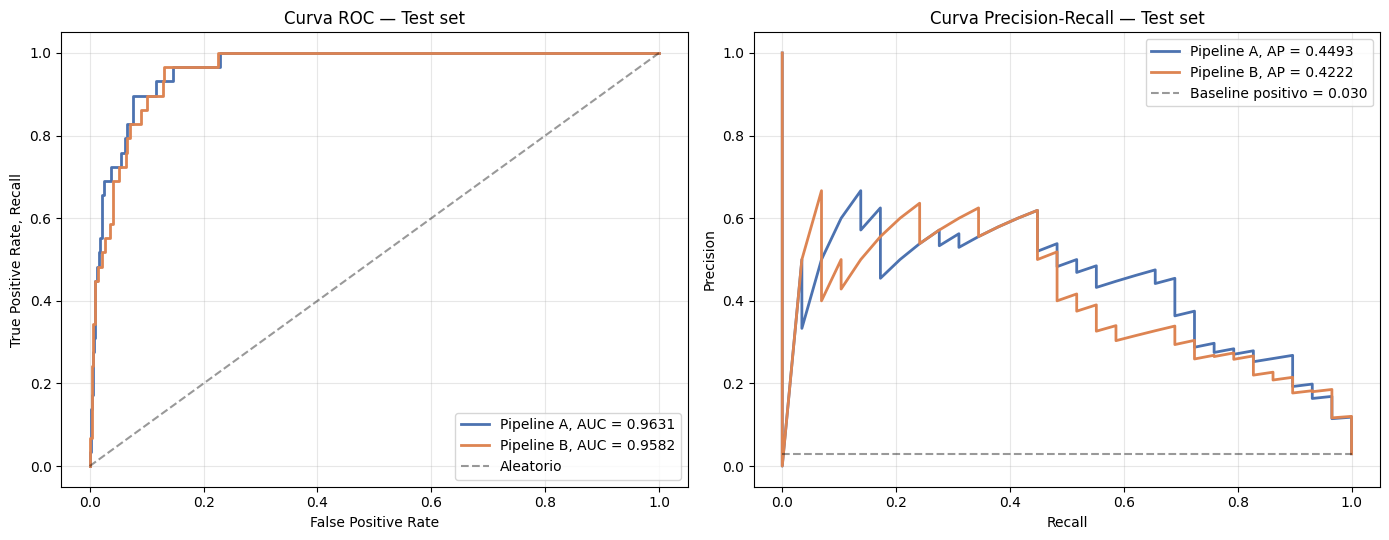

Análisis:
  La curva ROC resume separación global, pero en este problema la curva Precision-Recall
  es especialmente importante porque la clase acusatoria es minoritaria.
  Average Precision compara mejor la calidad del ranking para detectar positivos.


In [20]:
# Evaluación final en test set
from sklearn.metrics import (
    accuracy_score, average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve
)

pipeline_a_opt.fit(X_train, y_train)
pipeline_b_opt.fit(X_train_emb, y_train)

y_pred_a = pipeline_a_opt.predict(X_test)
y_score_a = pipeline_a_opt.predict_proba(X_test)[:, 1]

y_pred_b = pipeline_b_opt.predict(X_test_emb)
y_score_b = pipeline_b_opt.decision_function(X_test_emb)

def compute_test_metrics(y_true, y_pred, y_score):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_score),
        'Average Precision': average_precision_score(y_true, y_score),
        'Precision macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-Macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-Weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

m_a = compute_test_metrics(y_test, y_pred_a, y_score_a)
m_b = compute_test_metrics(y_test, y_pred_b, y_score_b)

print('=' * 80)
print(f'Tabla de métricas — Test set final ({len(y_test)} muestras)')
print('=' * 80)
print(f"{'Métrica':<22} {'Pipeline A':>16} {'Pipeline B':>16} {'Mejor':>8}")
print('-' * 68)
for metric in m_a:
    va, vb = m_a[metric], m_b[metric]
    mejor = 'A' if va > vb else ('B' if vb > va else '=')
    print(f'{metric:<22} {va:>16.4f} {vb:>16.4f} {mejor:>8}')
print('=' * 80)

print('\nReferencia CV, media ± desviación estándar:')
print(f"{'Métrica':<22} {'Pipeline A':>24} {'Pipeline B':>24}")
print('-' * 74)
for name, key in {
    'AUC-ROC': 'roc_auc',
    'Precision macro': 'precision_macro',
    'Recall macro': 'recall_macro',
    'F1-Macro': 'f1_macro',
    'Accuracy': 'accuracy',
}.items():
    a_s = cv_a_opt[f'test_{key}']
    b_s = cv_b_opt[f'test_{key}']
    print(f'{name:<22} {a_s.mean():>8.4f} ± {a_s.std():.4f}       {b_s.mean():>8.4f} ± {b_s.std():.4f}')

fpr_a, tpr_a, _ = roc_curve(y_test, y_score_a)
fpr_b, tpr_b, _ = roc_curve(y_test, y_score_b)
prec_a, rec_a, _ = precision_recall_curve(y_test, y_score_a)
prec_b, rec_b, _ = precision_recall_curve(y_test, y_score_b)
base_rate = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].plot(fpr_a, tpr_a, lw=2, color='#4C72B0', label=f'Pipeline A, AUC = {m_a["AUC-ROC"]:.4f}')
axes[0].plot(fpr_b, tpr_b, lw=2, color='#DD8452', label=f'Pipeline B, AUC = {m_b["AUC-ROC"]:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatorio')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate, Recall')
axes[0].set_title('Curva ROC — Test set')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(rec_a, prec_a, lw=2, color='#4C72B0', label=f'Pipeline A, AP = {m_a["Average Precision"]:.4f}')
axes[1].plot(rec_b, prec_b, lw=2, color='#DD8452', label=f'Pipeline B, AP = {m_b["Average Precision"]:.4f}')
axes[1].hlines(base_rate, 0, 1, colors='black', linestyles='--', alpha=0.4,
               label=f'Baseline positivo = {base_rate:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — Test set')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Análisis:')
print('  La curva ROC resume separación global, pero en este problema la curva Precision-Recall')
print('  es especialmente importante porque la clase acusatoria es minoritaria.')
print('  Average Precision compara mejor la calidad del ranking para detectar positivos.')

## 7. Conclusiones y Referencias

## Conclusiones

**Modelo ganador.** El modelo ganador debe decidirse por las métricas del test set y por la comparación pareada en validación cruzada. Pipeline A tiene una ventaja conceptual clara cuando los coeficientes muestran palabras y bigramas asociados al tono acusatorio: la señal parece más léxica que semántica.

**Feature selection.** La justificación de selección de features queda reforzada porque no solo se mencionan `min_df`, `max_df` y `max_features`; también se reporta el vocabulario final y los coeficientes más importantes. Esto conecta directamente el desempeño del modelo con evidencia interpretable.

**Pipelines.** Ambos enfoques usan estructuras de sklearn: Pipeline A integra TF-IDF y Regresión Logística; Pipeline B integra escalamiento y SVM sobre embeddings previamente generados. Esta separación es adecuada porque SentenceTransformer no es un transformador nativo de sklearn.

**t-SNE.** No se agrega t-SNE para Regresión Logística porque sería una proyección del espacio TF-IDF, no del clasificador. Para TF-IDF + LogReg, los coeficientes son más honestos y explicativos. El t-SNE sí se usa en embeddings, donde permite revisar si el espacio semántico preentrenado separa visualmente las clases.

**Limitaciones.** La clase acusatoria es pequeña, el dataset está fuertemente desbalanceado y los embeddings usados son generales, no especializados en español jurídico o administrativo. Además, la validación cruzada repetida ayuda a comparar modelos, pero no reemplaza al test set final.

**Mejoras futuras.** Las mejoras más prometedoras son recolectar más ejemplos acusatorios, probar fine-tuning de BETO o RoBERTa-es, calibrar umbrales según el costo de falsos positivos y falsos negativos, y validar los coeficientes con expertos del dominio.

## Referencias

[1] F. Pedregosa *et al.*, "Scikit-learn: Machine Learning in Python," *Journal of Machine Learning Research*, vol. 12, pp. 2825–2830, 2011.

[2] N. Reimers and I. Gurevych, "Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks," in *Proc. 2019 Conf. Empirical Methods Natural Language Processing (EMNLP)*, Hong Kong, China, 2019, pp. 3982–3992.

[3] C. D. Manning, P. Raghavan, and H. Schütze, *Introduction to Information Retrieval*. Cambridge, UK: Cambridge University Press, 2008.

[4] C. Cortes and V. Vapnik, "Support-vector networks," *Machine Learning*, vol. 20, no. 3, pp. 273–297, Sep. 1995.

[5] L. J. P. van der Maaten and G. E. Hinton, "Visualizing data using t-SNE," *Journal of Machine Learning Research*, vol. 9, pp. 2579–2605, Nov. 2008.

[6] F. Wilcoxon, "Individual comparisons by ranking methods," *Biometrics Bulletin*, vol. 1, no. 6, pp. 80–83, Dec. 1945.

[7] J. Demšar, "Statistical comparisons of classifiers over multiple data sets," *Journal of Machine Learning Research*, vol. 7, pp. 1–30, Jan. 2006.

[8] J. Cañete, G. Chaperon, R. Fuentes, J.-H. Ho, H. Kang, and J. Pérez, "Spanish pre-trained BERT model and evaluation data," in *Proc. PML4DC at ICLR 2020*, Addis Ababa, Ethiopia, 2020.